PHẦN 1: KHỞI TẠO VÀ XỬ LÝ DỮ LIỆU

In [4]:
#Khởi tạo dữ liệu(Data Generation)
import numpy as np
import pandas as pd

np.random.seed(42)

n_samples = 500

ma_kh = [f'KH{i:03d}' for i in range(1, n_samples + 1)]


tuoi = np.random.randint(18, 71, size=n_samples).astype(float)

idx_tuoi_nan = np.random.choice(n_samples, 10, replace=False)
tuoi[idx_tuoi_nan] = np.nan


thu_nhap = np.random.uniform(5_000_000, 50_000_000, size=n_samples)

idx_outliers = np.random.choice(n_samples, 5, replace=False)
thu_nhap[idx_outliers] = 200_000_000
gioi_tinh = np.random.choice(['Nam', 'Nữ'], size=n_samples).astype(object)

idx_gioi_tinh_nan = np.random.choice(n_samples, 15, replace=False)
gioi_tinh[idx_gioi_tinh_nan] = np.nan

thanh_pho = np.random.choice(['Hà Nội', 'Đà Nẵng', 'TP.HCM'], size=n_samples)


tong_chi_tieu = thu_nhap * 0.4 + np.random.uniform(1_000_000, 10_000_000, size=n_samples)

df_khachhang = pd.DataFrame({
    'MaKH': ma_kh,
    'Tuoi': tuoi,
    'ThuNhap': thu_nhap,
    'GioiTinh': gioi_tinh,
    'ThanhPho': thanh_pho,
    'TongChiTieu': tong_chi_tieu
})

print("--- 5 dòng đầu tiên của tập dữ liệu vừa khởi tạo ---")
print(df_khachhang.head())

--- 5 dòng đầu tiên của tập dữ liệu vừa khởi tạo ---
    MaKH  Tuoi       ThuNhap GioiTinh ThanhPho   TongChiTieu
0  KH001  56.0  1.986568e+07       Nữ  Đà Nẵng  1.245161e+07
1  KH002  69.0  4.701613e+07      Nam  Đà Nẵng  2.327606e+07
2  KH003  46.0  5.339046e+06       Nữ  Đà Nẵng  6.199102e+06
3  KH004  32.0  1.513998e+07       Nữ  Đà Nẵng  1.192866e+07
4  KH005  60.0  2.144106e+07       Nữ  Đà Nẵng  1.096373e+07


In [5]:
#Xử lý giá trị khuyết(Missing Values)

print("--- Số lượng giá trị khuyết trước khi xử lý ---")
print(df_khachhang.isnull().sum())

median_tuoi = df_khachhang['Tuoi'].median()
df_khachhang['Tuoi'].fillna(median_tuoi, inplace=True)
print(f"\n-> Đã điền khuyết cột 'Tuoi' bằng giá trị Trung vị: {median_tuoi}")

mode_gioi_tinh = df_khachhang['GioiTinh'].mode()[0]
df_khachhang['GioiTinh'].fillna(mode_gioi_tinh, inplace=True)
print(f"-> Đã điền khuyết cột 'GioiTinh' bằng giá trị Yếu vị (Mode): '{mode_gioi_tinh}'")

print("\n--- Số lượng giá trị khuyết sau khi xử lý ---")
print(df_khachhang.isnull().sum())

--- Số lượng giá trị khuyết trước khi xử lý ---
MaKH            0
Tuoi           10
ThuNhap         0
GioiTinh       15
ThanhPho        0
TongChiTieu     0
dtype: int64

-> Đã điền khuyết cột 'Tuoi' bằng giá trị Trung vị: 45.0
-> Đã điền khuyết cột 'GioiTinh' bằng giá trị Yếu vị (Mode): 'Nữ'

--- Số lượng giá trị khuyết sau khi xử lý ---
MaKH           0
Tuoi           0
ThuNhap        0
GioiTinh       0
ThanhPho       0
TongChiTieu    0
dtype: int64


/tmp/ipykernel_852/3591674730.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_khachhang['Tuoi'].fillna(median_tuoi, inplace=True)
/tmp/ipykernel_852/3591674730.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)',

In [6]:
#Mã hóa biến phân loại(Categorical Encoding)
thanhpho_dummies = pd.get_dummies(df_khachhang['ThanhPho'], prefix='ThanhPho', dtype=int)

df_khachhang = pd.concat([df_khachhang, thanhpho_dummies], axis=1)

print("--- Câu 3: Kết quả sau khi One-Hot Encoding cột ThanhPho ---")
print(df_khachhang.head())


--- Câu 3: Kết quả sau khi One-Hot Encoding cột ThanhPho ---
    MaKH  Tuoi       ThuNhap GioiTinh ThanhPho   TongChiTieu  ThanhPho_Hà Nội  \
0  KH001  56.0  1.986568e+07       Nữ  Đà Nẵng  1.245161e+07                0   
1  KH002  69.0  4.701613e+07      Nam  Đà Nẵng  2.327606e+07                0   
2  KH003  46.0  5.339046e+06       Nữ  Đà Nẵng  6.199102e+06                0   
3  KH004  32.0  1.513998e+07       Nữ  Đà Nẵng  1.192866e+07                0   
4  KH005  60.0  2.144106e+07       Nữ  Đà Nẵng  1.096373e+07                0   

   ThanhPho_TP.HCM  ThanhPho_Đà Nẵng  
0                0                 1  
1                0                 1  
2                0                 1  
3                0                 1  
4                0                 1  


In [7]:
#Phát hiện và xử lý điểm dị biệt(Outlier Detection)
Q1 = df_khachhang['ThuNhap'].quantile(0.25)
Q3 = df_khachhang['ThuNhap'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_khachhang = df_khachhang[(df_khachhang['ThuNhap'] >= lower_bound) & (df_khachhang['ThuNhap'] <= upper_bound)]

print(f"\n--- Câu 4: Xử lý Outlier cột ThuNhap ---")
print(f"Giới hạn dưới: {lower_bound:,.0f} VNĐ | Giới hạn trên: {upper_bound:,.0f} VNĐ")
print(f"Số lượng dòng còn lại sau khi lọc outlier: {len(df_khachhang)}")



--- Câu 4: Xử lý Outlier cột ThuNhap ---
Giới hạn dưới: -15,826,436 VNĐ | Giới hạn trên: 73,011,542 VNĐ
Số lượng dòng còn lại sau khi lọc outlier: 495


In [8]:
#Chuẩn hóa dữ liệu(Feature Scaling)
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_khachhang['TongChiTieu_Scaled'] = scaler.fit_transform(df_khachhang[['TongChiTieu']])

print("\n--- Câu 5: Kết quả sau khi chuẩn hóa cột TongChiTieu ---")
print(df_khachhang[['TongChiTieu', 'TongChiTieu_Scaled']].head())


--- Câu 5: Kết quả sau khi chuẩn hóa cột TongChiTieu ---
    TongChiTieu  TongChiTieu_Scaled
0  1.245161e+07            0.348602
1  2.327606e+07            0.751745
2  6.199102e+06            0.115736
3  1.192866e+07            0.329126
4  1.096373e+07            0.293188


In [9]:
#Lọc dữ liệu theo điều kiện(Data Filtering)
df_filtered = df_khachhang[(df_khachhang['GioiTinh'] == 'Nữ') &
                           (df_khachhang['Tuoi'] > 30) &
                           (df_khachhang['ThanhPho'] == 'Hà Nội')]

print("\n--- Câu 6: 5 dòng đầu tiên của danh sách khách hàng thỏa mãn điều kiện ---")
print(df_filtered.head())


--- Câu 6: 5 dòng đầu tiên của danh sách khách hàng thỏa mãn điều kiện ---
     MaKH  Tuoi       ThuNhap GioiTinh ThanhPho   TongChiTieu  \
13  KH014  70.0  3.636327e+07       Nữ   Hà Nội  1.606413e+07   
16  KH017  41.0  3.091993e+07       Nữ   Hà Nội  2.206573e+07   
32  KH033  66.0  2.884280e+07       Nữ   Hà Nội  1.289226e+07   
35  KH036  45.0  8.928058e+06       Nữ   Hà Nội  6.620971e+06   
43  KH044  54.0  2.970149e+07       Nữ   Hà Nội  1.400398e+07   

    ThanhPho_Hà Nội  ThanhPho_TP.HCM  ThanhPho_Đà Nẵng  TongChiTieu_Scaled  
13                1                0                 0            0.483146  
16                1                0                 0            0.706668  
32                1                0                 0            0.365014  
35                1                0                 0            0.131448  
43                1                0                 0            0.406419  


In [10]:
#Gom nhóm và Thống kê(Aggregation)
thong_ke_thanhpho = df_khachhang.groupby('ThanhPho')['TongChiTieu'].agg(['mean', 'sum'])

print("\n--- Câu 7: Thống kê TongChiTieu theo từng ThanhPho ---")
print(thong_ke_thanhpho)


--- Câu 7: Thống kê TongChiTieu theo từng ThanhPho ---
                  mean           sum
ThanhPho                            
Hà Nội    1.696743e+07  2.952334e+09
TP.HCM    1.698897e+07  2.820169e+09
Đà Nẵng   1.655785e+07  2.566466e+09


In [11]:
#Kỹ nghệ đặc trưng(Feature Engineering)
import seaborn as sns
import matplotlib.pyplot as plt

bins = [17, 30, 45, 60, float('inf')]
labels = ['18-30', '31-45', '46-60', 'Trên 60']

df_khachhang['NhomTuoi'] = pd.cut(df_khachhang['Tuoi'], bins=bins, labels=labels)

print("--- Câu 8: Kết quả phân nhóm tuổi (NhomTuoi) ---")
print(df_khachhang[['Tuoi', 'NhomTuoi']].head())

--- Câu 8: Kết quả phân nhóm tuổi (NhomTuoi) ---
   Tuoi NhomTuoi
0  56.0    46-60
1  69.0  Trên 60
2  46.0    46-60
3  32.0    31-45
4  60.0    46-60


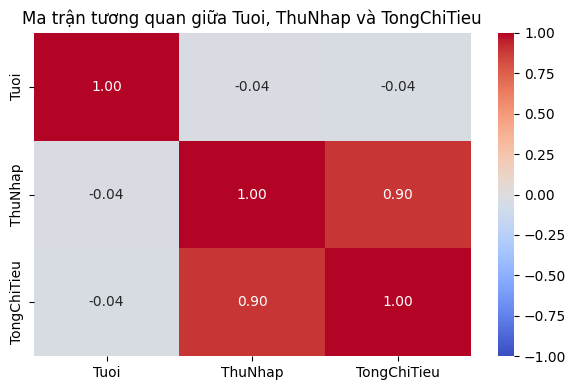

In [12]:
# Ma trận tương quan (Correlation Matrix)
numerical_features = ['Tuoi', 'ThuNhap', 'TongChiTieu']
correlation_matrix = df_khachhang[numerical_features].corr(method='pearson')

plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Ma trận tương quan giữa Tuoi, ThuNhap và TongChiTieu')
plt.tight_layout()
plt.show()

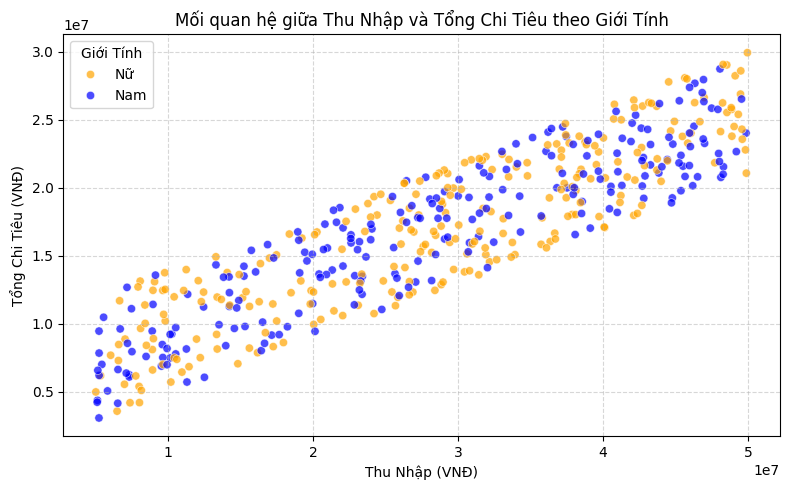

In [13]:
#Trực quan hóa dữ liệu (Data Visualization)
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_khachhang,
    x='ThuNhap',
    y='TongChiTieu',
    hue='GioiTinh',
    palette={'Nam': 'blue', 'Nữ': 'orange'},
    alpha=0.7
)

plt.title('Mối quan hệ giữa Thu Nhập và Tổng Chi Tiêu theo Giới Tính')
plt.xlabel('Thu Nhập (VNĐ)')
plt.ylabel('Tổng Chi Tiêu (VNĐ)')
plt.legend(title='Giới Tính')
plt.grid(True, linestyle='--', alpha=0.5)

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()

PHẦN 2: ỨNG DỤNG HỌC Sâu - MẠNG NƠ-RON TÍCH CHẬP

In [14]:
#Xây dựng và Huấn luyện mô hình CNN (Hình ảnh)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# 1. Tiền xử lý dữ liệu
fashion_mnist = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("Kích thước tập train sau tiền xử lý:", X_train.shape)
print("Kích thước tập test sau tiền xử lý:", X_test.shape)

# 2. Xây dựng kiến trúc CNN
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))
model.summary()

# 3. Biên dịch và Huấn luyện
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("\n--- Bắt đầu huấn luyện mô hình CNN ---")
model.fit(X_train, y_train, epochs=5, batch_size=64)

# 4. Đánh giá mô hình
print("\n--- Đánh giá mô hình trên tập kiểm thử ---")
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Độ chính xác (Accuracy) trên tập kiểm thử: {test_acc * 100:.2f}%")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Kích thước tập train sau tiền xử lý: (60000, 28, 28, 1)
Kích thước tập test sau tiền xử lý: (10000, 28, 28, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       346,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,146 (1.32 MB)

 Trainable params: 347,146 (1.32 MB)

 Non-trainable params: 0 (0.00 B)


--- Bắt đầu huấn luyện mô hình CNN ---
Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 37s 37ms/step - accuracy: 0.8484 - loss: 0.4305
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 36s 32ms/step - accuracy: 0.8969 - loss: 0.2878
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 40s 31ms/step - accuracy: 0.9106 - loss: 0.2476
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 31ms/step - accuracy: 0.9203 - loss: 0.2196
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 29s 31ms/step - accuracy: 0.9286 - loss: 0.1957

--- Đánh giá mô hình trên tập kiểm thử ---
Độ chính xác (Accuracy) trên tập kiểm thử: 90.68%
